In [2]:
# STEP 1 — IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
# STEP 2 — LOAD DATASET

df = pd.read_csv(r"C:\Users\LUKESH\OneDrive\Desktop\Telecom-Customer-Churn-Analysis\data\cleaned\Telco-Customer-Churn-Cleaned.csv")

print(df.head())
print("Dataset Shape:", df.shape)

   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingMovies  \
0  No phone service             DSL             No  ...              No   
1                No             DSL            Yes  ...              No   
2                No             DSL            Yes  ...              No   
3  No phone service             DSL            Yes  ...              No   
4                No     Fiber optic             No  ...              No   

         Contract PaperlessBilling              PaymentMethod MonthlyCharg

In [4]:
# STEP 3 — UNDERSTAND DATA

df.info()

print("\nColumns:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   str    
 1   gender               7043 non-null   str    
 2   SeniorCitizen        7043 non-null   str    
 3   Partner              7043 non-null   str    
 4   Dependents           7043 non-null   str    
 5   tenure               7043 non-null   int64  
 6   PhoneService         7043 non-null   str    
 7   MultipleLines        7043 non-null   str    
 8   InternetService      7043 non-null   str    
 9   OnlineSecurity       7043 non-null   str    
 10  OnlineBackup         7043 non-null   str    
 11  DeviceProtection     7043 non-null   str    
 12  TechSupport          7043 non-null   str    
 13  StreamingTV          7043 non-null   str    
 14  StreamingMovies      7043 non-null   str    
 15  Contract             7043 non-null   str    
 16 

In [5]:
# STEP 4 — CHECK MISSING VALUES

print(df.isnull().sum())

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
ChurnFlag              0
TenureGroup            0
MonthlyChargesGroup    0
dtype: int64


In [6]:
# STEP 5 — CHECK TARGET

# ChurnFlag: 0 = Stayed, 1 = Churned

print(df["ChurnFlag"].value_counts())
print(df["ChurnFlag"].value_counts(normalize=True) * 100)

ChurnFlag
0    5174
1    1869
Name: count, dtype: int64
ChurnFlag
0    73.463013
1    26.536987
Name: proportion, dtype: float64


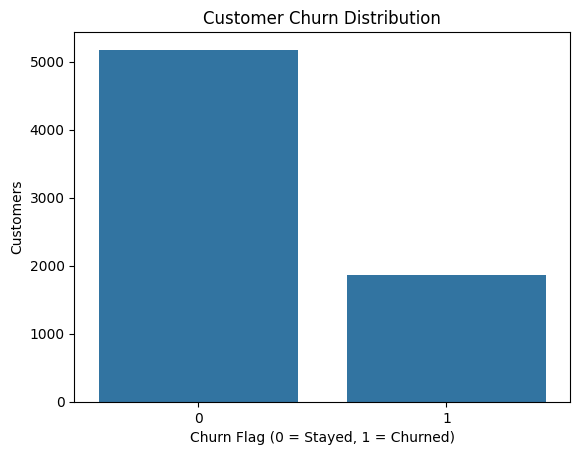

In [7]:
# STEP 6 — CHURN VISUALIZATION

sns.countplot(x="ChurnFlag", data=df)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Flag (0 = Stayed, 1 = Churned)")
plt.ylabel("Customers")
plt.show()

In [8]:
# STEP 7 — REMOVE IDENTIFIERS, TARGET LEAKAGE AND GROUPED COLUMNS

# customerID is only an identifier.
df = df.drop("customerID", axis=1)

# IMPORTANT:
# Churn contains the answer (Yes/No).
# ChurnFlag is our target, so keeping Churn would cause target leakage.
if "Churn" in df.columns:
    df = df.drop("Churn", axis=1)

# We already have the original numerical columns,
# so these derived groups are not used in the ML model.
for column in ["TenureGroup", "MonthlyChargesGroup"]:
    if column in df.columns:
        df = df.drop(column, axis=1)

print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']


In [9]:
# STEP 8 — HANDLE MISSING VALUES

df = df.dropna()
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [10]:
# STEP 9 — CREATE FEATURES AND TARGET

X = df.drop("ChurnFlag", axis=1)
y = df["ChurnFlag"]

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Target: ChurnFlag


In [11]:
# STEP 10 — IDENTIFY COLUMN TYPES

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "str"]).columns

print("Numerical:", numerical_cols.tolist())
print("Categorical:", categorical_cols.tolist())

Numerical: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
# STEP 11 — ONE-HOT ENCODING

# Convert categorical text into numerical columns.
X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

# Convert True/False into 1/0.
X_encoded = X_encoded.astype(int)

print(X_encoded.head())

   tenure  MonthlyCharges  TotalCharges  gender_Male  SeniorCitizen_Yes  \
0       1              29            29            0                  0   
1      34              56          1889            1                  0   
2       2              53           108            1                  0   
3      45              42          1840            1                  0   
4       2              70           151            0                  0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  MultipleLines_Yes  ...  \
0                               1                  0  ...   
1                               0                  0  ...   
2                               0                  0 

In [13]:
# STEP 12 — VERIFY TARGET LEAKAGE IS GONE

print("Churn_Yes:", "Churn_Yes" in X_encoded.columns)
print("Churn_No:", "Churn_No" in X_encoded.columns)
print("ChurnFlag:", "ChurnFlag" in X_encoded.columns)

# All three should be False.

Churn_Yes: False
Churn_No: False
ChurnFlag: False


In [14]:
# STEP 13 — TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Customers:", len(X_train))
print("Testing Customers:", len(X_test))

Training Customers: 5634
Testing Customers: 1409


In [15]:
# STEP 14 — CREATE AND TRAIN MODEL

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


c:\Users\LUKESH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# STEP 15 — MAKE PREDICTIONS

y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [17]:
# STEP 16 — MODEL METRICS

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("===================================")
print(" CORRECTED CUSTOMER CHURN ML MODEL")
print("===================================")
print("Training Customers:", len(X_train))
print("Testing Customers:", len(X_test))
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")
print("Recall   :", round(recall * 100, 2), "%")
print("F1 Score :", round(f1 * 100, 2), "%")
print("===================================")

 CORRECTED CUSTOMER CHURN ML MODEL
Training Customers: 5634
Testing Customers: 1409
Accuracy : 80.48 %
Precision: 65.52 %
Recall   : 55.88 %
F1 Score : 60.32 %


In [18]:
# STEP 17 — CLASSIFICATION REPORT

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [19]:
# STEP 18 — CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
print(cm)

TN, FP, FN, TP = cm.ravel()

print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)
print("True Positives :", TP)

[[925 110]
 [165 209]]
True Negatives : 925
False Positives: 110
False Negatives: 165
True Positives : 209


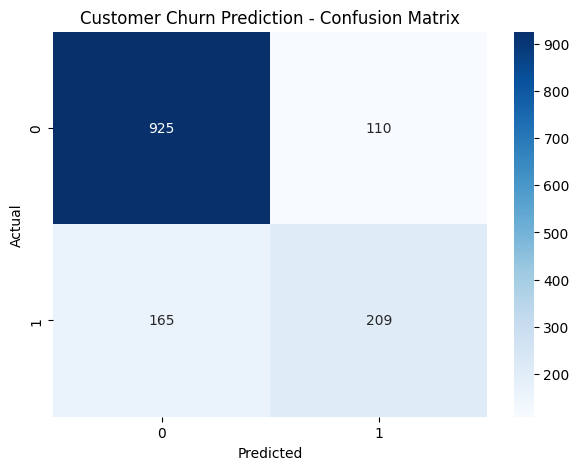

In [20]:
# STEP 19 — CONFUSION MATRIX VISUALIZATION

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Customer Churn Prediction - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
# STEP 20 — FEATURE COEFFICIENTS

coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

print(feature_importance.head(10))

                           Feature  Coefficient
10     InternetService_Fiber optic     0.734686
28  PaymentMethod_Electronic check     0.386886
26            PaperlessBilling_Yes     0.375995
9                MultipleLines_Yes     0.273452
23             StreamingMovies_Yes     0.200875
21                 StreamingTV_Yes     0.200868
8   MultipleLines_No phone service     0.162985
4                SeniorCitizen_Yes     0.147817
29      PaymentMethod_Mailed check     0.075603
5                      Partner_Yes     0.023756


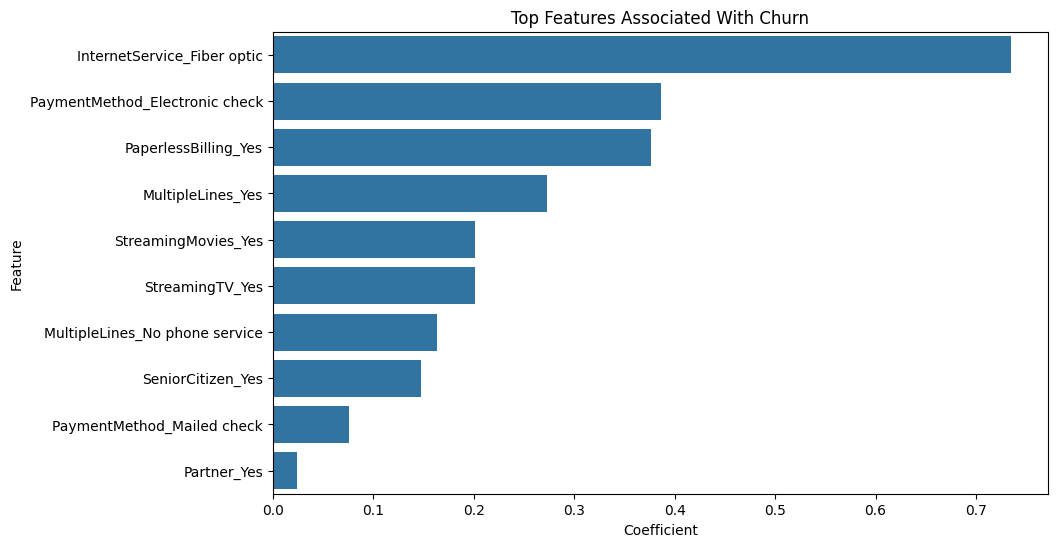

In [22]:
# STEP 21 — TOP FEATURES VISUALIZATION

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)
plt.title("Top Features Associated With Churn")
plt.show()

In [23]:
# STEP 22 — CHURN PROBABILITY

# [:, 1] selects probability of class 1 = Churn.
churn_probability = model.predict_proba(X_test)[:, 1]

print(churn_probability[:10])

[0.04654148 0.68217922 0.06379646 0.38992628 0.02067642 0.59985918
 0.44156533 0.12567537 0.00268886 0.39662952]


In [24]:
# STEP 23 — PREDICTION RESULTS

prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred,
    "Churn_Probability": churn_probability * 100
})

print(prediction_results.head(20))

    Actual_Churn  Predicted_Churn  Churn_Probability
0              0                0           4.654148
1              0                1          68.217922
2              0                0           6.379646
3              0                0          38.992628
4              0                0           2.067642
5              0                1          59.985918
6              0                0          44.156533
7              0                0          12.567537
8              0                0           0.268886
9              1                0          39.662952
10             0                0          27.482453
11             0                0           6.414144
12             0                0          12.460815
13             1                1          68.256142
14             0                0          12.544969
15             0                0           5.774844
16             0                0           3.286738
17             0                1          64.

In [25]:
# STEP 24 — RISK LEVELS

def risk_level(probability):
    if probability >= 70:
        return "High Risk"
    elif probability >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

prediction_results["Risk_Level"] = (
    prediction_results["Churn_Probability"].apply(risk_level)
)

print(prediction_results.head(20))

    Actual_Churn  Predicted_Churn  Churn_Probability   Risk_Level
0              0                0           4.654148     Low Risk
1              0                1          68.217922  Medium Risk
2              0                0           6.379646     Low Risk
3              0                0          38.992628     Low Risk
4              0                0           2.067642     Low Risk
5              0                1          59.985918  Medium Risk
6              0                0          44.156533  Medium Risk
7              0                0          12.567537     Low Risk
8              0                0           0.268886     Low Risk
9              1                0          39.662952     Low Risk
10             0                0          27.482453     Low Risk
11             0                0           6.414144     Low Risk
12             0                0          12.460815     Low Risk
13             1                1          68.256142  Medium Risk
14        

In [26]:
# STEP 25 — HIGH-RISK CUSTOMERS

high_risk_customers = prediction_results[
    prediction_results["Risk_Level"] == "High Risk"
]

print(high_risk_customers.head(20))
print("Total High-Risk Customers:", len(high_risk_customers))

     Actual_Churn  Predicted_Churn  Churn_Probability Risk_Level
20              1                1          72.407244  High Risk
27              1                1          70.098825  High Risk
29              1                1          77.345126  High Risk
34              1                1          77.977776  High Risk
38              1                1          75.718286  High Risk
41              0                1          79.148632  High Risk
46              0                1          71.003014  High Risk
51              1                1          71.276382  High Risk
83              1                1          78.897371  High Risk
100             1                1          76.518743  High Risk
124             1                1          70.179121  High Risk
154             1                1          77.709429  High Risk
171             1                1          74.986067  High Risk
182             1                1          73.018589  High Risk
224             0        

Risk_Level
Low Risk       972
Medium Risk    344
High Risk       93
Name: count, dtype: int64


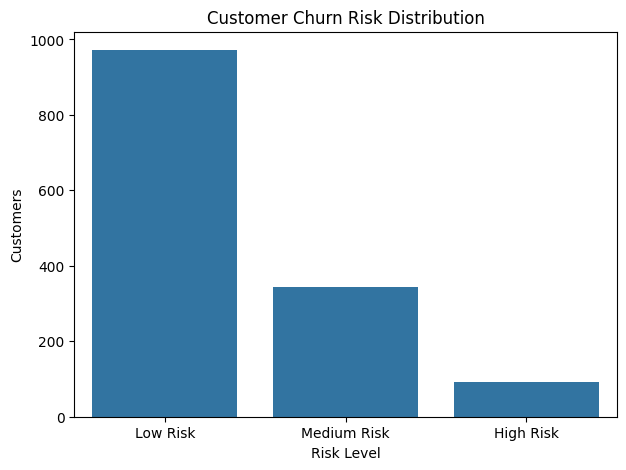

In [27]:
# STEP 26 — RISK DISTRIBUTION

print(prediction_results["Risk_Level"].value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(data=prediction_results, x="Risk_Level")
plt.title("Customer Churn Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Customers")
plt.show()

In [28]:
# STEP 27 — SAVE PREDICTIONS

prediction_results.to_csv(
    "../data/churn_predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!
